In [37]:
import yfinance as yf
import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

In [5]:
assets = ['COO', 'COST', 'JPM', 'NFLX', 'NVDA', 'SLB', 'SRE', 'UPS', 'GLDM', 'SPLG']
data = yf.download(assets, start='2024-09-03', end='2025-09-03')['Close']

/var/folders/yv/t6lmyq65615f04y252_c9llc0000gn/T/ipykernel_34011/1815795227.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(assets, start='2024-09-03', end='2025-09-03')['Close']
[*********************100%***********************]  10 of 10 completed


In [11]:
returns = np.log(data).diff()
return_vector = returns.mean() * 252
cov_matrix = returns.cov() * 252


In [53]:
mu_vec = np.asarray(return_vector).reshape(-1)
Sigma = .5 * (cov_matrix + cov_matrix.T)
Sigma += 1e-10 * np.eye(Sigma.shape[0])

n = len(mu_vec)
w = cp.Variable(n)
mu_star = cp.Parameter()

constraints = [
    cp.sum(w) == 1,
    w >= 0.05,
    w <= 0.15,
    cp.abs(mu_vec @ w - mu_star) <= 1e-6
]
objective = cp.Minimize(cp.quad_form(w, Sigma))
problem = cp.Problem(objective, constraints)

In [54]:
mus = np.linspace(0, 0.4, 100)
weight_list = []
risk_list = []
ret_list = []

for mu in mus:
    mu_star.value = mu
    problem.solve(solver=cp.OSQP, verbose=False)
    if problem.status not in ["optimal", "optimal_inaccurate"]:
        weight_list.append(None)  # infeasible at this mu
        risk_list.append(np.nan)
        ret_list.append(np.nan)
        continue
    w_opt = w.value
    weight_list.append(w_opt)
    ret_list.append(float(mu_vec @ w_opt))
    risk_list.append(float(w_opt.T @ Sigma @ w_opt))

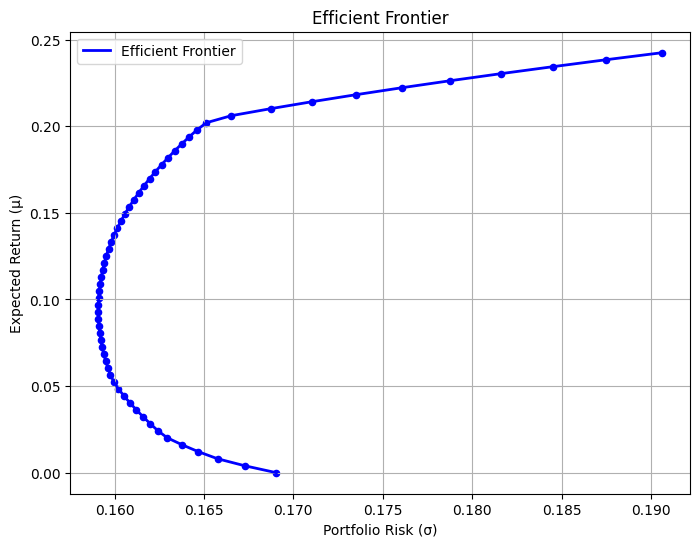

In [55]:
risks = np.sqrt(np.array(risk_list))  # convert variance → std dev
rets = np.array(ret_list)

plt.figure(figsize=(8, 6))
plt.plot(risks, rets, "b-", lw=2, label="Efficient Frontier")
plt.scatter(risks, rets, c="blue", s=20)

plt.xlabel("Portfolio Risk (σ)")
plt.ylabel("Expected Return (μ)")
plt.title("Efficient Frontier")
plt.legend()
plt.grid(True)
plt.show()

In [56]:
sharpe_ratios = rets / risks
max_sharpe_idx = np.nanargmax(sharpe_ratios)
max_sharpe_risk = risks[max_sharpe_idx]
max_sharpe_return = rets[max_sharpe_idx]
max_sharpe_weights = weight_list[max_sharpe_idx]

In [57]:
sharpe_ratios[max_sharpe_idx]

np.float64(1.271805459514099)

In [58]:
max_sharpe_return

np.float64(0.2424119668900491)

In [59]:
max_sharpe_weights

array([0.04998388, 0.05761516, 0.15000563, 0.15000411, 0.15001131,
       0.1500058 , 0.04999171, 0.1423985 , 0.04999692, 0.04998698])

In [60]:
capital = 1166.56

# Put into DataFrame
allocations = pd.DataFrame(
    {
        "Asset": assets,
        "Weight": max_sharpe_weights,
        "Capital Allocation ($)": max_sharpe_weights * capital,
    }
)

print(allocations)

  Asset    Weight  Capital Allocation ($)
0   COO  0.049984               58.309199
1  COST  0.057615               67.211540
2   JPM  0.150006              174.990571
3  NFLX  0.150004              174.988798
4  NVDA  0.150011              174.997191
5   SLB  0.150006              174.990766
6   SRE  0.049992               58.318323
7   UPS  0.142399              166.116396
8  GLDM  0.049997               58.324411
9  SPLG  0.049987               58.312808
